# LLM-Based Actuarial Report Generation Through Hugging Face

**Authors:** Jasper Lok ([jasper.jh.lok@gmail.com](mailto:jasper.jh.lok@gmail.com)), Thu Hoang ([thu9hoang@gmail.com](mailto:thu9hoang@gmail.com))  
**Date:** 29 Jan 2026  
**Version:** 1.1  
**Last executed:** 29 May 2026  


## Table of Contents


[1. Overview of Local Hugging Face Report Generation](#1-overview-of-local-hugging-face-report-generation)

[2. Hugging Face Demonstration](#2-hugging-face-demonstration)

[2.1. Local Setup and Data Preparation](#21-local-setup-and-data-preparation)

[2.2. CPU-Friendly Hugging Face Report Generation](#22-cpu-friendly-hugging-face-report-generation)

[3. Conclusion](#3-conclusion)


## 1. Overview of Local Hugging Face Report Generation

LLM-based report generation uses a large language model to draft narrative commentary from structured facts, calculations, and reviewer instructions. In an actuarial reporting context, the model should not be treated as the calculator or source of truth. Instead, it acts as a drafting layer that converts validated metrics, movement analysis, and business rules into clear management commentary.

This notebook is the local open-model version of the report-generation use case. It demonstrates how an actuarial reporting workflow can combine deterministic Python calculations with an open instruction model loaded through Hugging Face `transformers`.

The central design principle is to separate calculation from narration. Python reads the MAS G1 workbook, validates the required inputs, calculates year-on-year movements, creates the KPI table, and produces the chart. The local model is then used to convert those structured facts into management-oriented commentary. This avoids asking the model to perform arithmetic directly, which reduces the risk of unsupported figures or inconsistent calculations.

The raw MAS G1 extraction and cleaning steps are maintained in a separate companion notebook, `data-cleaning.ipynb`. This report-generation notebook assumes that those cleaning steps have already been completed and focuses on KPI calculation, controlled prompting, LLM-generated commentary, and Word report production.

For actuaries, this pattern can shorten the first-draft reporting cycle while preserving professional control over the numerical basis. Instead of starting commentary from a blank page, the actuary can review a model-generated draft that is anchored to the same KPI table used in the report. This can improve consistency across reporting periods, make recurring movement analysis faster, and help teams focus review time on business interpretation, assumptions, and management actions. It is particularly useful for recurring management packs, regulatory movement analysis, board papers, and valuation reporting where the structure is repeatable but the commentary still requires professional judgment.

The default model is `Qwen/Qwen2.5-3B-Instruct`. This is deliberately larger than very small CPU demo models because the use case needs coherent executive commentary rather than simple classification. It is still materially lighter than a 7B model and is therefore a more practical default for a local CPU demonstration. Users with more memory and longer runtime tolerance can set `HF_MODEL_NAME` to another compatible instruction model, such as `Qwen/Qwen2.5-7B-Instruct`.

This demonstration generates a report from structured MAS G1 facts and actuarial review instructions only. It does not demonstrate ingesting past reports to mimic a house writing style; that would require a separate document-ingestion workflow, style-source approval, and additional governance controls.

### Open-vs-closed LLM comparison

| Dimension | Local/open LLM approach | Hosted/closed LLM approach |
|---|---|---|
| Quality | May need tighter prompts, factual scaffolding, and more review to reach polished executive wording. | Often produces more fluent first drafts and stronger instruction-following out of the box. |
| Privacy | Can keep data within the local environment if the model and dependencies are already available locally. | Requires review of data-sharing, retention, and vendor controls before sending inputs to an API. |
| Cost | Avoids per-token API charges, but may require local compute, storage, and setup time. | Introduces usage-based API cost and monitoring requirements. |
| Reproducibility | More controllable when model files, package versions, seeds, and hardware/backend details are pinned. | Can still vary across model snapshots, service changes, or hosted infrastructure even with deterministic settings. |
| Fine-tuning | Open weights may allow local adaptation where licensing, skills, and compute permit. | Fine-tuning options depend on the provider, model family, and enterprise policy. |
| Compliance | Easier to evidence data locality, but model provenance, licensing, and validation still require review. | May offer enterprise controls and audit features, but needs vendor due diligence and internal approval. |

## 2. Hugging Face Demonstration


The example uses publicly available MAS insurance company return data. MAS G1 is a regulatory return used to report general insurance revenue account information, including premiums, claims, expenses, underwriting results, and operating results. The MAS source page is available [here](https://www.mas.gov.sg/statistics/insurance-statistics/insurance-company-returns). The figures in this notebook are for illustration and learning purposes only; they are not investment advice, regulatory advice, or a substitute for actuarial review.

The code chunks below locate the local project folder, import the required packages, validate the input files, prepare the selected company and fund data, generate charts, and load a Hugging Face instruction model to draft the management report. The generated report is intentionally supported by an audit JSON file so the reviewer can see the factual draft supplied to the model and the text returned by the model.

The interpretation in this case study should be read as a movement analysis of MAS G1 results. For 2023, the overall operating result improves materially because investment income moves from a loss to a positive contribution, while underwriting performance remains broadly stable. For 2024, underwriting performance improves because earned premium growth remains ahead of claims growth, but the operating result softens slightly because investment income is lower and expenses continue to rise. The purpose of the LLM is to turn these calculated facts into management-ready wording, not to create new facts or replace actuarial review.


### 2.1. Local Setup and Data Preparation


### Project Directory Structure Prerequisite

Before running the setup code below, ensure your local directory is organised as follows. The script dynamically looks for the `Data` and `Knowledge` directories to load regulatory files and supporting knowledge files.

The upstream extraction and cleaning workflow is documented in `data-cleaning.ipynb`. Run that notebook first when rebuilding `Data/Output_MAS_G1.xlsx` from raw MAS form workbooks.

```text
your-project-folder/
|
|-- Data/
|   `-- Output_MAS_G1.xlsx           # Raw MAS company returns workbook
|
|-- Knowledge/
|   |-- List of Formula.docx         # Actuarial formula references
|   `-- Mapping.xlsx                 # Company code to name mapping
|
`-- report-generation_local-llm.ipynb # This notebook file
```

This notebook creates the Word report directly from the calculated facts and generated commentary. It creates a fresh report document directly from the calculated facts and generated commentary. It does not demonstrate how to ingest past reports to mimic a prior writing style.

The setup code is organised into six chunks:

1. Locate the project folder dynamically so the notebook can run from another local PC.
2. Import the Python libraries used for data preparation, plotting, Word document creation, and Hugging Face generation.
3. Validate the required local input files and select the company/fund used in the demonstration.
4. Read the MAS workbook and supporting formula document.
5. Build a year-by-year MAS G1 data table for the selected company and fund.
6. Plot the key MAS G1 movements using `matplotlib`; the LLM is not used for numerical calculation or charting.

In [1]:
# Locate the project folder dynamically so the notebook can run on another local PC.
# Recommended: start Jupyter from the project folder that contains the Data and Knowledge folders.
# Alternative: set REPORT_GENERATION_PROJECT_DIR to the project folder path before running the notebook.
from pathlib import Path
import os
import logging
import warnings

# Suppress runtime warning/log noise in notebook exports.
# Set these before importing libraries that may emit TensorFlow, Transformers, tokenizer, or dependency warnings.
os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("tokenizers").setLevel(logging.ERROR)

try:
    from absl import logging as absl_logging
    absl_logging.set_verbosity(absl_logging.ERROR)
except ImportError:
    pass

from datasets import disable_progress_bar, enable_progress_bar

# Disable notebook widget progress bars so exported results stay clean.
disable_progress_bar()

def find_project_dir() -> Path:
    env_dir = os.getenv("REPORT_GENERATION_PROJECT_DIR")
    if env_dir:
        candidate = Path(env_dir).expanduser().resolve()
        if (candidate / "Data").is_dir() and (candidate / "Knowledge").is_dir():
            return candidate
        raise FileNotFoundError(
            "REPORT_GENERATION_PROJECT_DIR is set, but it does not contain both Data and Knowledge folders: "
            f"{candidate}"
        )

    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Data").is_dir() and (candidate / "Knowledge").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project folder. Start Jupyter from the folder that contains Data and Knowledge, "
        "or set REPORT_GENERATION_PROJECT_DIR to that folder path."
    )


PROJECT_DIR = find_project_dir()
os.chdir(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / "Data"
KNOWLEDGE_DIR = PROJECT_DIR / "Knowledge"
OUTPUT_DIR = PROJECT_DIR / "Output"
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
# Import the required libraries for local data preparation, charting, Word-document handling, and Hugging Face generation.
# Lightweight data packages are installed automatically if missing. Hugging Face model packages are checked separately because torch/model downloads can be large.
import importlib.util
import json
import math
import os
import re
import subprocess
import sys
from datetime import date
from pathlib import Path

required_packages = {
    "pandas": "pandas",
    "openpyxl": "openpyxl",
    "docx": "python-docx",
    "matplotlib": "matplotlib",
}

missing_packages = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

import matplotlib.pyplot as plt
import pandas as pd
from docx import Document
from docx.shared import Inches

HF_REQUIRED_MODULES = {
    "transformers": "transformers",
    "torch": "torch",
}

HF_MISSING_PACKAGES = [package for module, package in HF_REQUIRED_MODULES.items() if importlib.util.find_spec(module) is None]
HF_PACKAGES_AVAILABLE = len(HF_MISSING_PACKAGES) == 0
HF_INSTALL_HELP = (
    "Hugging Face local generation requires transformers and torch in the active Python environment. "
    "Install the missing package(s), restart the kernel, and rerun. Missing: " + ", ".join(HF_MISSING_PACKAGES)
    if HF_MISSING_PACKAGES else ""
)


In [3]:
# Read in all necessary local files.
results_path = DATA_DIR / "Output_MAS_G1.xlsx"
formula_path = KNOWLEDGE_DIR / "List of Formula.docx"
mapping_path = KNOWLEDGE_DIR / "Mapping.xlsx"
required_files = [results_path, formula_path, mapping_path]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError("Missing required local file(s): " + ", ".join(missing_files))

# Select the company and fund to demonstrate. Change these values to analyse another sheet.
selected_company_code = "TMG"
selected_fund_code = "SIF"

def get_company_name(mapping_file: Path, company_code: str) -> str:
    mapping_raw = pd.read_excel(mapping_file, header=None)
    header_row = mapping_raw[mapping_raw.apply(lambda row: row.astype(str).str.contains("Code", case=False, na=False).any(), axis=1)].index[0]
    mapping = mapping_raw.iloc[header_row + 1:].copy()
    mapping.columns = mapping_raw.iloc[header_row].astype(str).str.strip()
    mapping = mapping.rename(columns=lambda col: str(col).strip())
    match = mapping.loc[mapping["Code"].astype(str).str.strip() == company_code, "Company Name"]
    return match.iloc[0].strip() if not match.empty else company_code

selected_company_name = get_company_name(mapping_path, selected_company_code)
print(f"Analysing {selected_company_name} ({selected_company_code}, {selected_fund_code})")

Analysing TOKIO MARINE INSURANCE SINGAPORE LTD (TMG, SIF)


In [4]:
# Read in the necessary background information.
xls = pd.ExcelFile(results_path)
doc = Document(formula_path)

formula = "\n".join([para.text for para in doc.paragraphs if para.text.strip()])

In [5]:
# Build a year-by-year view for the selected company and fund.
selected_prefix = f"{selected_company_code}_{selected_fund_code}_"
selected_sheets = sorted(
    [sheet for sheet in xls.sheet_names if sheet.startswith(selected_prefix)],
    key=lambda sheet: int(re.search(r"(\d{4})$", sheet).group(1)),
)

if not selected_sheets:
    raise ValueError(f"No sheets found for prefix {selected_prefix}. Available sheets include: {xls.sheet_names[:5]}")

combined = None

for sheet in selected_sheets:
    df = pd.read_excel(xls, sheet_name=sheet)

    section_col = "Section" if "Section" in df.columns else None
    desc_col = "Description" if "Description" in df.columns else df.columns[0]
    total_candidates = [col for col in df.columns if str(col).strip().lower() == "total"]
    if not total_candidates:
        raise KeyError(f"Could not find a Total column in sheet {sheet}. Columns found: {list(df.columns)}")
    total_col = total_candidates[0]

    year = re.search(r"(\d{4})$", sheet).group(1)
    keep_cols = [col for col in [section_col, desc_col, total_col] if col is not None]
    slim = df[keep_cols].copy()
    slim.columns = (["Section"] if section_col is not None else []) + ["Description", year]

    merge_keys = ["Section", "Description"] if "Section" in slim.columns else ["Description"]
    combined = slim if combined is None else combined.merge(slim, on=merge_keys, how="outer")

id_cols = [col for col in ["Section", "Description"] if col in combined.columns]
year_cols = sorted([col for col in combined.columns if col not in id_cols])
combined = combined[id_cols + year_cols]
display(combined)

,Section,Description,2022,2023,2024
0,DISTRIBUTION EXPENSES/ (INCOME),Commission expenses,25231143,27465606,31646537
1,DISTRIBUTION EXPENSES/ (INCOME),Net commission expenses/ (income) (30 - 31),9053336,10771289,13378581
2,DISTRIBUTION EXPENSES/ (INCOME),Other distribution expenses/ (income),1306513,2126975,2725428
3,DISTRIBUTION EXPENSES/ (INCOME),Reinsurance commission income,16177807,16694317,18267956
4,DISTRIBUTION EXPENSES/ (INCOME),Total distribution expenses/ (income) (32 + 33),10359849,12898264,16104009
5,Gross Claims settled,Total (16 to 18),510066,495869,769468
6,Gross Claims settled,Other ASEAN countries,0,0,0
7,Gross Claims settled,Other countries,0,0,0
8,Gross Claims settled,Singapore,510066,495869,769468
9,Gross Claims settled,Direct business,72716089,68911415,81379846


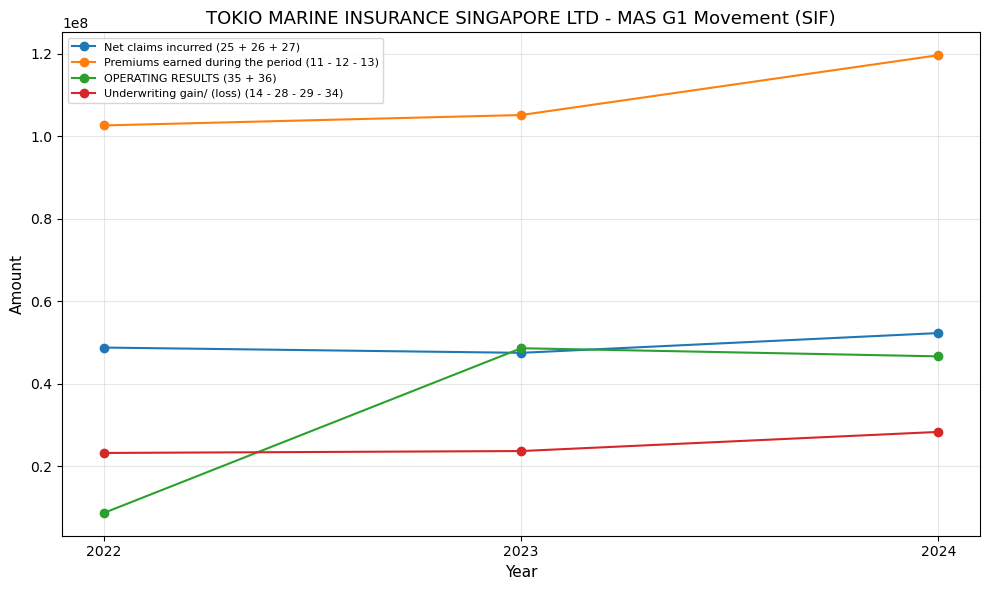

In [6]:
# Generate charts for the report.
# Visualisations require numerical precision and faithful rendering, so plotting is delegated to matplotlib.
# The LLM is only used for prose commentary, not chart generation or numerical calculation.
metrics_to_plot = [
    "Total gross premiums (1 + 5)",
    "Premiums earned during the period (11 - 12 - 13)",
    "Net claims incurred (25 + 26 + 27)",
    "Underwriting gain/ (loss) (14 - 28 - 29 - 34)",
    "OPERATING RESULTS (35 + 36)",
]

metric_source = combined[combined["Description"].isin(metrics_to_plot)].drop(columns=["Section"], errors="ignore")
metric_df = metric_source.set_index("Description").T
metric_df = metric_df.apply(pd.to_numeric, errors="coerce")

chart_file = OUTPUT_DIR / f"{selected_company_code}_{selected_fund_code}_G1_2022_2024.png"

plt.figure(figsize=(10, 6))
for metric in metric_df.columns:
    plt.plot(metric_df.index, metric_df[metric], marker="o", linestyle="-", label=metric)

plt.title(f"{selected_company_name} - MAS G1 Movement ({selected_fund_code})", fontsize=13)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Amount", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(chart_file, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 2.2. CPU-Friendly Hugging Face Report Generation

This is the main report-generation workflow for Notebook 2. The code calculates structured year-on-year facts from the MAS G1 workbook and uses a local Hugging Face instruction model to draft the executive summary, year-on-year commentary, management review points, and key monitoring areas.

The report-generation concept has three layers:

1. **Fact layer:** Python extracts the relevant MAS G1 metrics and computes year-on-year movements. These calculations are deterministic and auditable.
2. **Prompt layer:** The calculated facts are converted into factual drafts and analyst notes. This gives the model a controlled basis for drafting instead of asking it to infer directly from a spreadsheet.
3. **Narrative layer:** Hugging Face `transformers` loads an instruction model and rewrites the factual drafts into management-oriented prose. The output is saved with an audit trail and inserted into the Word report.

This structure helps actuaries use LLMs where they add the most value: improving wording, structure, and first-draft speed. The actuary remains responsible for the conclusions, especially where management context, reserving judgment, pricing actions, or portfolio changes are not visible in the public return data.

**Model choice.** The default model is `Qwen/Qwen2.5-3B-Instruct`. It is selected as a balanced CPU-oriented model: more capable for executive commentary than very small models, but less demanding than a 7B model. To use another compatible instruction model, set `HF_MODEL_NAME` before running the notebook.


**On reproducibility.** The local generation uses deterministic decoding (`do_sample=False`) and a fixed seed where supported. Even then, wording may vary if the model version, package versions, or hardware/backend changes. Keep the model name, package versions, prompts, generated text, and source facts in the audit trail.

**Execution note.** The notebook generates the Hugging Face report by default. The first run may download the selected Hugging Face model, which can take time and requires internet access unless the model is already cached. To test only the deterministic notebook sections without running model generation, set `RUN_HF_GENERATION=0` before executing the notebook.


In [7]:
# Generate a senior-management-ready Word report using a Hugging Face instruction model.
HF_MODEL_NAME = os.getenv("HF_MODEL_NAME", "Qwen/Qwen2.5-3B-Instruct")
# Generate the Hugging Face report by default. Set RUN_HF_GENERATION=0 to skip this heavy step.
RUN_HF_GENERATION = os.getenv("RUN_HF_GENERATION", "1") != "0"
HF_LOCAL_FILES_ONLY = os.getenv("HF_LOCAL_FILES_ONLY", "0") == "1"
MAX_INPUT_TOKENS = 4096
MAX_NEW_TOKENS = 512
SEED = 42
VALUE_DIVISOR = 1_000_000  # Output_MAS_G1.xlsx stores full dollars; divide by 1,000,000 to display S$m.

MANAGEMENT_REPORT_PROMPT = """
You are a senior general insurance valuation actuary with experience preparing management,
valuation committee and board-level commentary for insurance companies.

The target audience includes:
- CEO
- CFO
- Appointed Actuary
- senior insurance management

This is a formal regulatory management report. Write in third person throughout.
Do not use first-person language ("our", "we", "us") under any circumstances.

===============================================
COMMENTARY STANDARDS
===============================================

Write commentary that is:
- professional and formal in register;
- commercially focused and implication-driven;
- concise - one well-constructed paragraph per section, not a list of KPI movements;
- executive-oriented - the reader has already seen the KPI table.

The objective is not to restate numbers, but to explain:
- what changed and why it matters;
- whether the movement appears operationally sustainable or is period-specific;
- what management should monitor going forward, and why it is material.

===============================================
EXECUTIVE SUMMARY - SPECIFIC REQUIREMENTS
===============================================

The executive summary must follow this structure:

  Sentence 1 - State the operating result position across the full period
               in absolute dollar terms. Do not open with a percentage change.

  Sentence 2 - Separate the underwriting result trend from investment income.
               State whether underwriting margins improved or deteriorated and why.

  Sentence 3 - Explain the investment income contribution and whether it is
               a normalisation, a recovery, or a structural improvement.
               If the base year was negative or near-zero, explicitly note this
               so the percentage change is not misread as genuine growth.

  Sentence 4 - Identify the single most material cost pressure or risk
               and express it as a proportion of earned premiums, not
               just as a YoY percentage change.

  Sentence 5 - State the forward-looking management implication in one
               sentence. Be specific about what to monitor and why it is
               material to earnings quality.

===============================================
HANDLING NEAR-ZERO AND SIGN-CHANGE BASE YEARS
===============================================

If a metric moves from a negative or near-zero base to a positive value:
- Do NOT quote the percentage change as the headline figure.
- Instead, lead with the absolute dollar movement.
- Explicitly note that the base year was negative or distorted.
- Do not treat the movement as structural improvement without evidence.

Example of correct handling:
  "Investment income recovered from -S$14.5m in 2022 to S$24.9m in 2023,
   a normalisation following a loss year rather than a structural uplift."

===============================================
EXPENSE COMMENTARY REQUIREMENTS
===============================================

When commenting on expense movements:
- Always express the expense as a proportion of earned premiums for at least
  one reference year so management can assess materiality, not just direction.
- If an expense line has grown faster than earned premiums for two or more
  consecutive periods, explicitly state this as a multi-year trend.
- Do not flag an expense line only in the final sentence as an afterthought.
  If it is material enough to mention, structure it as a substantive point.

===============================================
MANAGEMENT REVIEW POINTS - SPECIFIC REQUIREMENTS
===============================================

Each management review point must follow this bullet structure:

- State the analytical conclusion first (what the data shows).
- Then state the action or monitoring implication.

Do NOT write review points as directives to "review", "assess", or "validate"
without first giving the pre-digested finding.

Incorrect format:
  "Review whether earned premium growth remains ahead of claims development."

Correct format:
  "Earned premium growth of 16.6% over the period has outpaced claims growth
   of 7.2%; however, the 2024 acceleration in claims warrants monitoring by
   line of business to confirm the margin trend is not narrowing."

===============================================
CORE ANALYTICAL FOCUS
===============================================

- underwriting profitability and margin direction;
- sustainability and quality of earnings;
- earned premium growth versus claims growth - express as a ratio or spread;
- expense efficiency - distribution and management expenses as % of earned premiums;
- investment earnings volatility and its contribution to operating result;
- emerging operational pressures or multi-year trends.

===============================================
ANALYTICAL SEQUENCING RULES
===============================================

In every section:
- Lead with the net analytical conclusion (what this means for the business).
- Then provide the supporting numbers.
- Then state the implication or monitoring point.

Never open a paragraph or section with a raw percentage change.
Never open with "For [year]..." - state the finding first.

When underwriting and investment both moved in the same period:
- Quantify the contribution of each in absolute dollar terms.
- State explicitly whether the operating result movement was driven by
  insurance operations or investment fluctuations.
- If investment income cushioned or amplified underwriting performance,
  say so directly.

===============================================
AVOIDED LANGUAGE - EXTENDED LIST
===============================================

Do not use informal intensifiers:
  "significant", "significant boost", "significantly improved",
  "substantial", "substantial recovery", "notable"

Do not use vague monitoring directives without a finding:
  "management should continue to closely monitor",
  "ongoing monitoring is warranted",
  "further scrutiny is required"

Do not use optimistic framing:
  "outperformance of growth", "substantial uplift",
  "strong resilience", "healthy growth trajectory",
  "remains robust"

Do not use passive constructions that obscure causality:
  "was largely offset by", "reduction was largely offset",
  "improvement was supported by"

Instead use active, causal language:
  "underwriting result improved by S$X, partially cushioning a S$Y fall
   in investment income" - not "the decline was offset by underwriting improvement"

===============================================
PREFERRED COMMENTARY STYLE - EXPANDED EXAMPLES
===============================================

Opening sentences:
  OK - "The fund returned to operating profitability in 2023, with the operating
     result recovering from S$8.7m to S$48.6m, driven by a normalisation in
     investment income following a loss year in 2022."
  OK - "Core underwriting profitability improved in 2024 despite a reduction in
     investment income contribution."

Underwriting commentary:
  OK - "Claims growth of 10.1% remained below earned premium growth of 13.8%,
     supporting an improvement in the underwriting result to S$28.3m."
  OK - "Underwriting margins were broadly flat in 2023; the operating result
     improvement was entirely investment-driven."

Expense commentary:
  OK - "Distribution expenses rose to S$16.1m, representing 13.5% of earned
     premiums against 10.1% in 2022, with two consecutive years of above-
     premium growth in this cost line."

Investment commentary:
  OK - "Investment income of S$24.9m in 2023 represents a normalisation from
     the -S$14.5m recorded in 2022 and should not be treated as a structural
     improvement in earnings quality."
  OK - "Operating performance remains partially dependent on investment income,
     which has shown material volatility across the three-year period."

Forward-looking sentences:
  OK - "The acceleration in distribution expense relative to earned premiums
     across both periods warrants management attention before this becomes
     a structural drag on underwriting margins."

===============================================
PROHIBITED TOPICS
===============================================

Do not introduce or speculate on:
- reserving or claims development patterns;
- pricing strategy or rate adequacy;
- reinsurance arrangements;
- portfolio diversification or risk selection;
- external market conditions or macroeconomic context.

Unless any of the above are explicitly stated in the factual inputs provided,
they must not appear in the commentary.

===============================================
SELF-REVIEW CHECKLIST - APPLY BEFORE FINALISING
===============================================

Before producing the final output, verify each of the following:

[ ] Does the executive summary open with the operating result in dollars,
    not a percentage change?
[ ] Is investment income clearly separated from underwriting performance
    in every section?
[ ] Has every near-zero or sign-change percentage been replaced with
    an absolute dollar movement plus a contextual note?
[ ] Are expenses expressed as a proportion of earned premiums at least once?
[ ] Does each management review point lead with the finding, not the directive?
[ ] Has the phrase "management should continue to closely monitor" been removed?
[ ] Has every informal intensifier ("significant", "substantial", "notable")
    been replaced with a quantified statement?
[ ] Is the commentary written entirely in third person?
[ ] Does every paragraph lead with the analytical conclusion,
    not with a year label or a raw number?
[ ] Would a senior actuary at the company be comfortable presenting
    this commentary at a board meeting without editing it?
"""


def calc_yoy_change(current, previous):
    if current is None or previous is None or previous == 0:
        return None
    return (current - previous) / abs(previous)

def fmt_money(value):
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return "n/a"
    sign = "-" if value < 0 else ""
    return f"{sign}S${abs(value) / VALUE_DIVISOR:.1f}m"


def fmt_abs_money(value):
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return "n/a"
    return f"S${abs(value) / VALUE_DIVISOR:.1f}m"


def fmt_pct(value):
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return "n/a"
    return f"{value * 100:+.1f}%"


def fmt_money_change(current, previous):
    if current is None or previous is None:
        return "n/a"
    return fmt_money(current - previous)


def classify_primary_operating_driver(prev, cur):
    underwriting_change = cur["Underwriting result"] - prev["Underwriting result"]
    investment_change = cur["Investment income"] - prev["Investment income"]
    if abs(investment_change) > abs(underwriting_change) * 1.25:
        primary = "investment income movement"
    elif abs(underwriting_change) > abs(investment_change) * 1.25:
        primary = "underwriting result movement"
    else:
        primary = "a combination of underwriting and investment movements"
    return (
        f"Operating result changed by {fmt_money_change(cur['Operating result'], prev['Operating result'])}. "
        f"Underwriting result changed by {fmt_money_change(cur['Underwriting result'], prev['Underwriting result'])}; "
        f"investment income changed by {fmt_money_change(cur['Investment income'], prev['Investment income'])}. "
        f"Primary operating-result driver based on absolute dollar movement: {primary}."
    )


def clean_generated_text(text):
    text = re.sub(r"(?is)<extra_id_\d+>", "", text)
    text = re.sub(r"^(Summary|Final text|Output):\s*", "", text.strip(), flags=re.IGNORECASE)
    text = text.replace("**", "")
    text = re.sub(r"(?m)^#{1,6}\s*", "", text)
    text = text.replace("  ", " ").strip()

    unsupported_fragments = [
        "asset allocation", "higher yields", "diversified portfolio", "strategic asset",
        "market conditions", "interest rate", "risk selection", "pricing strateg",
        "adequate financial buffer", "adequate reserves", "attributed to",
        "outperformed investment", "outpacing investment",
        "stronger underwriting discipline"
    ]
    cleaned_parts = []
    for part in re.split(r"(?<=[.!?])\s+", text):
        lower = part.lower()
        if any(fragment and fragment in lower for fragment in unsupported_fragments):
            continue
        cleaned_parts.append(part.strip())
    cleaned = " ".join(part for part in cleaned_parts if part).strip()
    return cleaned or text


def split_bullets(text, fallback):
    bullets = []
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("- "):
            bullets.append(line[2:].strip())
    if len(bullets) < 2:
        inline_bullets = re.findall(r"(?:^|\s)-\s+(.*?)(?=\s+-\s+|$)", text.strip())
        bullets = [item.strip() for item in inline_bullets if item.strip()]
    if not bullets and text.strip():
        bullets = [part.strip(" -") for part in re.split(r";|\n", text) if part.strip()]
    return bullets[:4] if len(bullets) >= 2 else fallback


metric_map = {
    "Gross premiums": "Total gross premiums (1 + 5)",
    "Net premiums written": "Net premiums written (6 - 10)",
    "Earned premiums": "Premiums earned during the period (11 - 12 - 13)",
    "Net claims incurred": "Net claims incurred (25 + 26 + 27)",
    "Management expenses": "Management Expenses",
    "Distribution expenses": "Total distribution expenses/ (income) (32 + 33)",
    "Underwriting result": "Underwriting gain/ (loss) (14 - 28 - 29 - 34)",
    "Investment income": "NET INVESTMENT INCOME/ (LOSS)",
    "Operating result": "OPERATING RESULTS (35 + 36)",
}

summary_rows = []
for year in sorted([int(col) for col in combined.columns if str(col).isdigit()]):
    row = {"Year": year}
    for label, description in metric_map.items():
        match = combined.loc[combined["Description"].astype(str).str.strip().eq(description), str(year)]
        if match.empty:
            raise KeyError(f"Could not find metric description: {description}")
        row[label] = float(match.iloc[0])
    summary_rows.append(row)
summary = pd.DataFrame(summary_rows).sort_values("Year")
if summary["Gross premiums"].max() < 1_000_000:
    raise ValueError("The workbook values look smaller than expected for full-dollar MAS G1 data. Check whether the source is stored in S$'000 and update VALUE_DIVISOR if needed.")


def analyst_notes_for_period(from_year, to_year):
    """Create factual analyst notes from calculated MAS G1 movements."""
    prev = summary.loc[summary["Year"] == from_year].iloc[0]
    cur = summary.loc[summary["Year"] == to_year].iloc[0]
    yoy = {metric: calc_yoy_change(cur[metric], prev[metric]) for metric in metric_map}

    premium_growth = yoy["Earned premiums"]
    claims_growth = yoy["Net claims incurred"]
    underwriting_growth = yoy["Underwriting result"]
    investment_growth = yoy["Investment income"]
    operating_growth = yoy["Operating result"]
    expense_growth = calc_yoy_change(
        cur["Management expenses"] + cur["Distribution expenses"],
        prev["Management expenses"] + prev["Distribution expenses"],
    )

    if premium_growth is not None and claims_growth is not None:
        premium_claims_read = "Earned premium growth exceeded net claims incurred growth." if premium_growth > claims_growth else "Net claims incurred growth exceeded earned premium growth."
    else:
        premium_claims_read = "Premium and claims growth comparison is not available."

    movement_candidates = {
        "operating_result": operating_growth,
        "underwriting_result": underwriting_growth,
        "investment_income": investment_growth,
        "earned_premiums": premium_growth,
        "net_claims_incurred": claims_growth,
        "combined_expenses": expense_growth,
    }
    ranked_movements = sorted(
        [(name, value) for name, value in movement_candidates.items() if value is not None],
        key=lambda item: abs(item[1]),
        reverse=True,
    )[:3]
    largest_movement_text = "; ".join(f"{name}: {fmt_pct(value)}" for name, value in ranked_movements)

    return "\n".join([
        f"Company: {selected_company_name}.",
        f"Fund: {selected_fund_code}.",
        f"Period: {to_year} vs {from_year}.",
        f"Operating result: {fmt_money(prev['Operating result'])} to {fmt_money(cur['Operating result'])} ({fmt_pct(operating_growth)}).",
        f"Gross premiums: {fmt_money(prev['Gross premiums'])} to {fmt_money(cur['Gross premiums'])} ({fmt_pct(yoy['Gross premiums'])}).",
        f"Earned premiums: {fmt_money(prev['Earned premiums'])} to {fmt_money(cur['Earned premiums'])} ({fmt_pct(premium_growth)}).",
        f"Net claims incurred: {fmt_money(prev['Net claims incurred'])} to {fmt_money(cur['Net claims incurred'])} ({fmt_pct(claims_growth)}).",
        f"Management expenses: {fmt_money(prev['Management expenses'])} to {fmt_money(cur['Management expenses'])} ({fmt_pct(yoy['Management expenses'])}).",
        f"Distribution expenses: {fmt_money(prev['Distribution expenses'])} to {fmt_money(cur['Distribution expenses'])} ({fmt_pct(yoy['Distribution expenses'])}).",
        f"Combined management and distribution expenses: {fmt_money(prev['Management expenses'] + prev['Distribution expenses'])} to {fmt_money(cur['Management expenses'] + cur['Distribution expenses'])} ({fmt_pct(expense_growth)}).",
        f"Underwriting result: {fmt_money(prev['Underwriting result'])} to {fmt_money(cur['Underwriting result'])} ({fmt_pct(underwriting_growth)}).",
        f"Investment income: {fmt_money(prev['Investment income'])} to {fmt_money(cur['Investment income'])} ({fmt_pct(investment_growth)}).",
        f"Premium versus claims: {premium_claims_read}",
        f"Largest calculated movements by absolute percentage: {largest_movement_text}.",
        classify_primary_operating_driver(prev, cur),
        "Instruction: Use these calculated facts to generate commercial commentary. Do not invent causes or external market context. Use the primary operating-result driver above when discussing what drove operating performance.",
    ])


all_notes = "\n\n".join(analyst_notes_for_period(from_year, to_year) for from_year, to_year in [(2022, 2023), (2023, 2024)])



local_llm_skip_reasons = []
hf_model_name = HF_MODEL_NAME
if not RUN_HF_GENERATION:
    local_llm_skip_reasons.append("RUN_HF_GENERATION is set to 0, so Hugging Face model generation was skipped for this execution.")
if not HF_PACKAGES_AVAILABLE:
    local_llm_skip_reasons.append(HF_INSTALL_HELP)

if local_llm_skip_reasons:
    print("Local Hugging Face report generation was not run because the following prerequisite(s) are missing or disabled:")
    for reason in local_llm_skip_reasons:
        print(f"- {reason}")
    print("After resolving the prerequisite(s), rerun this cell to generate the Hugging Face Word report and audit JSON.")
else:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed

    set_seed(SEED)
    print(f"Loading Hugging Face model: {hf_model_name}")
    tokenizer = AutoTokenizer.from_pretrained(
        hf_model_name,
        trust_remote_code=True,
        local_files_only=HF_LOCAL_FILES_ONLY,
    )
    model = AutoModelForCausalLM.from_pretrained(
        hf_model_name,
        torch_dtype="auto",
        trust_remote_code=True,
        local_files_only=HF_LOCAL_FILES_ONLY,
    )
    model.to("cpu")
    model.eval()
    generation_config = model.generation_config
    generation_config.do_sample = False
    generation_config.temperature = None
    generation_config.top_p = None
    generation_config.top_k = None


    def format_hf_prompt(task_instruction, notes):
        messages = [
            {"role": "system", "content": MANAGEMENT_REPORT_PROMPT.strip()},
            {
                "role": "user",
                "content": (
                    f"Task: {task_instruction}\n\n"
                    f"Use only these analyst notes:\n{notes}\n\n"
                    "Return only the requested report text. Do not add facts that are not in the analyst notes."
                ),
            },
        ]
        if getattr(tokenizer, "chat_template", None):
            return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        return f"System:\n{messages[0]['content']}\n\nUser:\n{messages[1]['content']}\n\nAssistant:\n"


    def hf_generate(task_instruction, notes, max_new_tokens=MAX_NEW_TOKENS):
        prompt = format_hf_prompt(task_instruction, notes)
        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_INPUT_TOKENS,
        )
        with torch.inference_mode():
            output_ids = model.generate(
                **inputs,
                generation_config=generation_config,
                max_new_tokens=max_new_tokens,
                repetition_penalty=1.05,
                pad_token_id=tokenizer.eos_token_id,
            )
        generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
        return clean_generated_text(tokenizer.decode(generated_ids, skip_special_tokens=True))

    def output_is_usable(text, min_chars=80, max_money_mentions=None, require_bullets=False):
        if not text or len(text.strip()) < min_chars:
            return False
        if text.count("(") != text.count(")"):
            return False
        if max_money_mentions is not None and text.count("S$") > max_money_mentions:
            return False
        if require_bullets and text.count("- ") < 2:
            return False
        lower_text = text.lower()
        # Replace broad string checks with tighter patterns
        if re.search(r"underwriting (result|profitability).{0,30}declin", lower_text):
            return False
        if re.search(r"underwriting.{0,20}primary driver.{0,20}investment", lower_text):
            return False
        if "claims development remained ahead" in lower_text or "claims growth exceeded earned premium growth" in lower_text:
            return False
        if "not sufficient to offset the decline in investment income" in lower_text:
            return False
        if "higher claims compared to earned premiums" in lower_text:
            return False
        if re.search(r"underwriting result movement.*driven by investment income", lower_text):
            return False
        if re.search(r"(from|to|and|while|S\$-?|S\$\d+\.)$", text.strip()):
            return False
        banned_fragments = [
            "outperformance of growth", "substantial uplift", "reduction was largely offset",
            "risk selection", "pricing strateg", "adequate reserves", "diversified investments",
            "outperformed investment", "outpacing investment", "lower investment contributions",
            "not sufficient to offset the decline in investment income", "higher claims compared to earned premiums",
        ]
        return not any(fragment in text.lower() for fragment in banned_fragments)


    def period_factual_draft(from_year, to_year):
        prev = summary.loc[summary["Year"] == from_year].iloc[0]
        cur = summary.loc[summary["Year"] == to_year].iloc[0]
        earned_yoy = calc_yoy_change(cur["Earned premiums"], prev["Earned premiums"])
        claims_yoy = calc_yoy_change(cur["Net claims incurred"], prev["Net claims incurred"])
        premium_claims = "earned premium growth exceeded claims growth" if earned_yoy is not None and claims_yoy is not None and earned_yoy > claims_yoy else "claims growth exceeded earned premium growth"
        return (
            f"For {to_year} vs {from_year}, operating result moved from {fmt_money(prev['Operating result'])} to {fmt_money(cur['Operating result'])}. "
            f"Underwriting result moved from {fmt_money(prev['Underwriting result'])} to {fmt_money(cur['Underwriting result'])}. "
            f"Earned premiums moved from {fmt_money(prev['Earned premiums'])} to {fmt_money(cur['Earned premiums'])}, while net claims incurred moved from {fmt_money(prev['Net claims incurred'])} to {fmt_money(cur['Net claims incurred'])}; {premium_claims}. "
            f"Management expenses moved from {fmt_money(prev['Management expenses'])} to {fmt_money(cur['Management expenses'])}, and distribution expenses moved from {fmt_money(prev['Distribution expenses'])} to {fmt_money(cur['Distribution expenses'])}. "
            f"Investment income moved from {fmt_money(prev['Investment income'])} to {fmt_money(cur['Investment income'])}. "
            f"{classify_primary_operating_driver(prev, cur)}"
        )


    def executive_factual_draft():
        # --- Three-year anchor figures ---
        anchor = (
            f"Company: {selected_company_name}. Fund: {selected_fund_code}. Period: 2022 to 2024.\n"
            f"Operating result:     2022 {fmt_money(by_year[2022]['Operating result'])}, "
            f"2023 {fmt_money(by_year[2023]['Operating result'])} "
            f"({fmt_pct(calc_yoy_change(by_year[2023]['Operating result'], by_year[2022]['Operating result']))}), "
            f"2024 {fmt_money(by_year[2024]['Operating result'])} "
            f"({fmt_pct(calc_yoy_change(by_year[2024]['Operating result'], by_year[2023]['Operating result']))}).\n"
            f"Underwriting result:  2022 {fmt_money(by_year[2022]['Underwriting result'])}, "
            f"2023 {fmt_money(by_year[2023]['Underwriting result'])} "
            f"({fmt_pct(calc_yoy_change(by_year[2023]['Underwriting result'], by_year[2022]['Underwriting result']))}), "
            f"2024 {fmt_money(by_year[2024]['Underwriting result'])} "
            f"({fmt_pct(calc_yoy_change(by_year[2024]['Underwriting result'], by_year[2023]['Underwriting result']))}).\n"
            f"Investment income:    2022 {fmt_money(by_year[2022]['Investment income'])}, "
            f"2023 {fmt_money(by_year[2023]['Investment income'])} "
            f"({fmt_pct(calc_yoy_change(by_year[2023]['Investment income'], by_year[2022]['Investment income']))}), "
            f"2024 {fmt_money(by_year[2024]['Investment income'])} "
            f"({fmt_pct(calc_yoy_change(by_year[2024]['Investment income'], by_year[2023]['Investment income']))}).\n"
            f"Earned premiums:      2022 {fmt_money(by_year[2022]['Earned premiums'])}, "
            f"2024 {fmt_money(by_year[2024]['Earned premiums'])} "
            f"({fmt_pct(calc_yoy_change(by_year[2024]['Earned premiums'], by_year[2022]['Earned premiums']))} over two years).\n"
            f"Net claims incurred:  2022 {fmt_money(by_year[2022]['Net claims incurred'])}, "
            f"2024 {fmt_money(by_year[2024]['Net claims incurred'])} "
            f"({fmt_pct(calc_yoy_change(by_year[2024]['Net claims incurred'], by_year[2022]['Net claims incurred']))} over two years).\n"
            f"Explicit accuracy check: underwriting result increased slightly from 2022 to 2023 and increased again from 2023 to 2024. Do not describe underwriting profitability as declining in either period.\n"
            f"Explicit accuracy check: the 2023 operating result improvement was mainly investment income recovery, not a step-change in underwriting profitability.\n"
        )

        # --- Analyst notes for both periods (already computed, wire them in) ---
        notes_2023 = analyst_notes_for_period(2022, 2023)
        notes_2024 = analyst_notes_for_period(2023, 2024)

        instruction = (
            "Instruction: Use the three-year anchor figures and both sets of analyst period notes above "
            "to write a concise executive summary. Separate underwriting performance from investment performance. "
            "Explain what drove the operating result in each year, whether underwriting margins improved or deteriorated, "
            "and what management should monitor. Do not invent causes or external market context."
        )

        return "\n\n".join([anchor, "Period notes 2023 vs 2022:\n" + notes_2023, "Period notes 2024 vs 2023:\n" + notes_2024, instruction])



    def review_factual_draft():
        ep_2022 = by_year[2022]["Earned premiums"]
        ep_2024 = by_year[2024]["Earned premiums"]
        claims_2022 = by_year[2022]["Net claims incurred"]
        claims_2024 = by_year[2024]["Net claims incurred"]
        dist_2022 = by_year[2022]["Distribution expenses"]
        dist_2024 = by_year[2024]["Distribution expenses"]
        uw_2022 = by_year[2022]["Underwriting result"]
        uw_2024 = by_year[2024]["Underwriting result"]
        inv_2022 = by_year[2022]["Investment income"]
        inv_2024 = by_year[2024]["Investment income"]

        ep_growth   = calc_yoy_change(ep_2024, ep_2022)
        cl_growth   = calc_yoy_change(claims_2024, claims_2022)
        dist_pct_22 = dist_2022 / ep_2022 * 100
        dist_pct_24 = dist_2024 / ep_2024 * 100
        dist_growth = calc_yoy_change(dist_2024, dist_2022)
        ep_vs_cl    = "outpaced" if ep_growth > cl_growth else "lagged behind"
        dist_vs_ep  = "exceeded" if dist_growth > ep_growth else "remained below"

        return "\n".join([
            # Point 1 - premium vs claims finding first, then the monitoring implication
            f"- Earned premium growth of {fmt_pct(ep_growth)} over 2022 to 2024 {ep_vs_cl} net claims growth of {fmt_pct(cl_growth)}, "
            f"from {fmt_money(ep_2022)} to {fmt_money(ep_2024)} and {fmt_money(claims_2022)} to {fmt_money(claims_2024)} respectively; "
            f"monitor by line of business to confirm the margin trend is not narrowing.",

            # Point 2 - distribution expense as % of earned premiums, not just a raw movement
            f"- Distribution expenses rose from {dist_pct_22:.1f}% to {dist_pct_24:.1f}% of earned premiums "
            f"({fmt_money(dist_2022)} to {fmt_money(dist_2024)}); distribution expense growth of {fmt_pct(dist_growth)} "
            f"{dist_vs_ep} earned premium growth of {fmt_pct(ep_growth)}, so management should assess whether this pressure is structural.",

            # Point 3 - separate underwriting from investment income as a quality-of-earnings point
            f"- Underwriting result of {fmt_money(uw_2024)} in 2024 should be assessed separately from investment income of {fmt_money(inv_2024)} "
            f"when evaluating operating result quality; investment income moved from {fmt_money(inv_2022)} in 2022 and has shown material "
            f"volatility across the period.",

            # Point 4 - line-of-business validation (unchanged, factual)
            "- Validate all movements by line of business before external publication; "
            "the fund-level figures do not distinguish between lines and may mask offsetting movements.",
        ])


    def monitoring_factual_draft():
        ep_2023 = by_year[2023]["Earned premiums"]
        ep_2024 = by_year[2024]["Earned premiums"]
        cl_2023 = by_year[2023]["Net claims incurred"]
        cl_2024 = by_year[2024]["Net claims incurred"]
        dist_2023 = by_year[2023]["Distribution expenses"]
        dist_2024 = by_year[2024]["Distribution expenses"]
        inv_2022 = by_year[2022]["Investment income"]
        inv_2023 = by_year[2023]["Investment income"]
        inv_2024 = by_year[2024]["Investment income"]
        op_2023  = by_year[2023]["Operating result"]
        op_2024  = by_year[2024]["Operating result"]

        ep_cl_gap   = calc_yoy_change(ep_2024, ep_2023) - calc_yoy_change(cl_2024, cl_2023)
        dist_vs_ep  = calc_yoy_change(dist_2024, dist_2023) - calc_yoy_change(ep_2024, ep_2023)
        inv_volatile = abs(inv_2023 - inv_2022) / VALUE_DIVISOR  # swing in S$m
        uw_share_24  = by_year[2024]["Underwriting result"] / op_2024 * 100 if op_2024 != 0 else 0

        return "\n".join([
            # Signal 1 - premium/claims gap with the 2024 acceleration noted
            f"- Premium growth exceeded claims growth by {fmt_pct(ep_cl_gap)} in 2024 "
            f"({fmt_pct(calc_yoy_change(ep_2024, ep_2023))} vs {fmt_pct(calc_yoy_change(cl_2024, cl_2023))}); "
            f"monitor whether this spread is maintained as claims development matures.",

            # Signal 2 - distribution expense acceleration relative to premiums
            f"- Distribution expense growth exceeded earned premium growth by {fmt_pct(dist_vs_ep)} in 2024; "
            f"if this trend continues it will compress underwriting margins regardless of premium volume.",

            # Signal 3 - investment income volatility with the 2022 loss year as context
            f"- Investment income swung by S${inv_volatile:.1f}m between 2022 and 2023 (from {fmt_money(inv_2022)} to {fmt_money(inv_2023)}); "
            f"operating result sustainability should not be assessed without separating underwriting from investment contributions.",

            # Signal 4 - earnings quality: how much of operating result is underwriting-sourced
            f"- Underwriting result represented {uw_share_24:.0f}% of the 2024 operating result; "
            f"monitor whether the underwriting share of earnings continues to improve or whether the fund remains partially dependent on investment income.",
        ])


    def hf_rewrite(section, task_instruction, factual_draft, max_new_tokens=MAX_NEW_TOKENS, require_bullets=False):
        instruction = task_instruction + " Rewrite the supplied factual draft only; preserve all figures exactly and do not add causes or external context. Do not use markdown headings."
        text = hf_generate(instruction, factual_draft, max_new_tokens=max_new_tokens)
        passes = output_is_usable(text, min_chars=40, require_bullets=require_bullets)
        retry_text = None
        if not passes:
            retry_text = hf_generate(
                instruction + " Keep the output shorter, preserve the relationship between underwriting and investment income, and complete every sentence.",
                factual_draft,
                max_new_tokens=max_new_tokens + 80,
            )
            retry_passes = output_is_usable(retry_text, min_chars=40, require_bullets=require_bullets)
            if retry_passes:
                text = retry_text
                passes = True
            else:
                text = factual_draft
        generation_audit[section] = {
            "factual_draft": factual_draft,
            "model_text": text,
            "retry_text": retry_text,
            "passes_basic_checks": passes,
        }
        return text


    generation_audit = {}
    by_year = {int(row["Year"]): row for _, row in summary.iterrows()}
    executive_summary = hf_rewrite(
        "executive_summary",
    (
        "Write one executive-summary paragraph of four to five sentences for senior management. "
        "Sentence 1: state the operating result in absolute dollars across 2022 to 2024 - do not open with a percentage. "
        "Sentence 2: underwriting result trend and margin direction. "
        "Sentence 3: investment income contribution - note if 2022 was a loss year so the recovery is not misread. "
        "Sentence 4: the most material cost pressure expressed as a proportion of earned premiums. "
        "Sentence 5: the forward-looking monitoring implication. "
        "Write in third person. Do not use markdown."
    ),
    executive_factual_draft(),
    max_new_tokens=420,
    )
    period_commentary_text = {
        "2023 vs 2022": hf_rewrite(
            "period_commentary_2023_vs_2022",
            (
                "Rewrite as two year-on-year commentary bullets, each starting with '- '. "
                "Bullet 1 must state what changed in the operating result, in dollar terms, and whether the change was driven by underwriting or investment income. "
                "Bullet 2 must state which specific items contributed to the change, including underwriting margin direction and any expense line growing faster than premiums. "
                "Write in third person. Do not use numbering. Do not open with 'For 2023'."
            ),
            period_factual_draft(2022, 2023),
            max_new_tokens=260,
            require_bullets=True,
        ),
        "2024 vs 2023": hf_rewrite(
            "period_commentary_2024_vs_2023",
            (
                "Rewrite as two year-on-year commentary bullets, each starting with '- '. "
                "Bullet 1 must state what changed in the operating result, in dollar terms, and identify the primary driver. "
                "Bullet 2 must state which specific items contributed to the change, including whether underwriting margins improved or deteriorated and the most material cost pressure. "
                "Write in third person. Do not use numbering. Do not open with 'For 2024'."
            ),
            period_factual_draft(2023, 2024),
            max_new_tokens=260,
            require_bullets=True,
        ),
    }
    period_commentary = {
        heading: split_bullets(text, [text])
        for heading, text in period_commentary_text.items()
    }
    review_points_text = hf_rewrite(
        "review_points",
        (
            "Rewrite as four management review bullets, each starting with '- '. "
            "Each bullet must lead with the analytical finding (what the data shows), "
            "then state the monitoring or action implication. "
            "Do not open any bullet with 'Review', 'Assess', or 'Validate' - "
            "state the finding first, then the action. "
            "Preserve all figures exactly. Write in third person. "
            "Complete every bullet as a full sentence."
        ),
        review_factual_draft(),
        max_new_tokens=300,   # raised from 150 - four complete bullets need ~250-280 tokens
        require_bullets=True,
    )

    review_points = split_bullets(review_points_text, [review_points_text])

    monitoring_points_text = hf_rewrite(
        "monitoring_points",
        (
            "Rewrite as four key monitoring-area bullets, each starting with '- '. "
            "Each bullet must identify a specific, quantified risk signal from the data, "
            "then explain why it matters to earnings quality or underwriting performance. "
            "Do not use generic phrases like 'monitor whether' without first stating "
            "what the current data signal already shows. "
            "Preserve all figures exactly. Write in third person. "
            "Complete every bullet as a full sentence."
        ),
        monitoring_factual_draft(),
        max_new_tokens=300,   # raised from 150
        require_bullets=True,
    )
 
    monitoring_points = split_bullets(monitoring_points_text, [monitoring_points_text])

    llm_audit_file = OUTPUT_DIR / f"{selected_company_code}_{selected_fund_code}_hf_commentary.json"
    llm_audit_file.write_text(json.dumps({
        "model_name": hf_model_name,
        "backend": "huggingface-transformers",
        "prompt_style": "senior general insurance valuation actuary management-report prompt",
        "generation_audit": generation_audit,
        "executive_summary": executive_summary,
        "period_commentary": period_commentary,
        "review_points": review_points,
        "monitoring_points": monitoring_points,
    }, ensure_ascii=False, indent=2), encoding="utf-8")

    report_file = OUTPUT_DIR / f"{selected_company_code}_{selected_fund_code}_G1_HF_Management_Report.docx"
    doc = Document()
    doc.add_heading(f"{selected_company_name} - MAS G1 Management Commentary", level=1)
    doc.add_paragraph(f"Insurance fund: {selected_fund_code} | Period reviewed: 2022 to 2024 | Prepared: {date.today():%d %B %Y}")

    doc.add_heading("Executive Summary", level=1)
    doc.add_paragraph(executive_summary)

    doc.add_heading("KPI Overview", level=1)
    table = doc.add_table(rows=1, cols=6)
    table.style = "Table Grid"
    headers = ["Metric", "2022", "2023", "YoY", "2024", "YoY"]
    for i, header in enumerate(headers):
        table.rows[0].cells[i].text = header
    by_year = {int(row["Year"]): row for _, row in summary.iterrows()}
    for metric in ["Gross premiums", "Earned premiums", "Net claims incurred", "Management expenses", "Distribution expenses", "Underwriting result", "Investment income", "Operating result"]:
        row = table.add_row().cells
        row[0].text = metric
        row[1].text = fmt_money(by_year[2022][metric])
        row[2].text = fmt_money(by_year[2023][metric])
        row[3].text = fmt_pct(calc_yoy_change(by_year[2023][metric], by_year[2022][metric]))
        row[4].text = fmt_money(by_year[2024][metric])
        row[5].text = fmt_pct(calc_yoy_change(by_year[2024][metric], by_year[2023][metric]))

    doc.add_heading("Year-on-Year Commentary", level=1)
    for heading, bullets in period_commentary.items():
        doc.add_heading(heading, level=2)
        for bullet in bullets:
            doc.add_paragraph(bullet, style="List Bullet")

    doc.add_heading("Financial Movement Chart", level=1)
    doc.add_picture(str(chart_file), width=Inches(6.4))

    doc.add_heading("Management Review Points", level=1)
    for point in review_points:
        doc.add_paragraph(point, style="List Bullet")

    doc.add_heading("Key Monitoring Areas / Emerging Risks", level=1)
    for point in monitoring_points:
        doc.add_paragraph(point, style="List Bullet")

    doc.add_heading("Scope and Limitations", level=1)
    doc.add_paragraph(f"This commentary was generated by a Hugging Face instruction model (`{hf_model_name}`) using structured MAS G1 facts derived from the local workbook. It is intended as a management-ready draft and should be reviewed against detailed line-of-business analysis, reserving information, reinsurance arrangements, and management explanations before publication.")

    doc.save(report_file)
    print(f"Saved Hugging Face management report")
    print(f"Saved Hugging Face commentary audit file")


Loading Hugging Face model: Qwen/Qwen2.5-3B-Instruct


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Saved Hugging Face management report
Saved Hugging Face commentary audit file


## 3. Conclusion


This notebook demonstrates a local Hugging Face workflow for actuarial report generation. The key pattern is to let Python calculate and validate the numbers, then let the model draft narrative from controlled factual inputs.

The example also highlights an important practical limitation: CPU-friendly open models may produce uneven prose or introduce unsupported wording. For actuarial use, this makes the audit trail and review process essential. A stronger model may improve drafting quality, but it does not remove the need for actuarial validation.

Several governance points remain important:

- **Validate every output:** LLM-generated commentary should be reviewed by an actuary for accuracy, completeness, and tone, including a figure-by-figure cross-check against the KPI table.

- **Ground the model in structured facts:** The model performs better when it receives validated metrics, year-on-year movements, and explicit analyst notes.

- **Separate calculation from narration:** Python should calculate the numbers and produce the charts; the local model should draft the wording.

- **Control reproducibility:** Use deterministic settings where supported, pin model and package versions, and retain the generated audit file.

- **Apply governance before publication:** Be aware that the IP status of LLM-generated text is an evolving area; actuarial work product that includes AI-generated commentary should be reviewed under the firm's AI governance policy before external publication.

Overall, a CPU-oriented Hugging Face instruction model can demonstrate local AI-assisted report generation, but actuarial judgment remains essential for validation, interpretation, and final approval.
